# IMPORT DATASET

In [ ]:
import pandas as pd

dataset = pd.read_csv("/content/hotel_bookings.csv")
dataset.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0.0,0.0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0.0,0.0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0.0,1.0,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0.0,1.0,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0.0,0.0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0.0,1.0,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0.0,1.0,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0.0,0.0,Canceled,2015-04-22


# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
print('Shape of the dataset is {}.'.format(dataset.shape))
print(f'This dataset contains {dataset.shape[0]} rows (data points) and {dataset.shape[1]} columns (features).')

Shape of the dataset is (119390, 32).
This dataset contains 119390 rows (data points) and 32 columns (features).


# **Dataset Information**

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
# Split numerical features
numerical_data = dataset.select_dtypes(include='number')
numerical_features = numerical_data.columns.tolist()
print(f'There are {len(numerical_features)} QUANTITATIVE (numerical) features:\n')
print(numerical_features)

print("\n" + "="*60)

# Split categorical features
categorical_data = dataset.select_dtypes(include='object')
categorical_features = categorical_data.columns.tolist()
print(f'\nThere are {len(categorical_features)} CATEGORICAL features:\n')
print(categorical_features)

print("\n" + "="*60)

There are 20 QUANTITATIVE (numerical) features:

['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


There are 12 CATEGORICAL features:

['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']



In [ ]:
print("Categorical Features and their unique values:\n")
for col in categorical_features:
    print(f"  {col}: {dataset[col].nunique()} unique values → {dataset[col].unique()[:5]} ...")

Categorical Features and their unique values:

  hotel: 2 unique values → ['Resort Hotel' 'City Hotel'] ...
  arrival_date_month: 12 unique values → ['July' 'August' 'September' 'October' 'November'] ...
  meal: 5 unique values → ['BB' 'FB' 'HB' 'SC' 'Undefined'] ...
  country: 177 unique values → ['PRT' 'GBR' 'USA' 'ESP' 'IRL'] ...
  market_segment: 8 unique values → ['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary'] ...
  distribution_channel: 5 unique values → ['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS'] ...
  reserved_room_type: 10 unique values → ['C' 'A' 'D' 'E' 'G'] ...
  assigned_room_type: 12 unique values → ['C' 'A' 'D' 'E' 'G'] ...
  deposit_type: 3 unique values → ['No Deposit' 'Refundable' 'Non Refund'] ...
  customer_type: 4 unique values → ['Transient' 'Contract' 'Transient-Party' 'Group'] ...
  reservation_status: 3 unique values → ['Check-Out' 'Canceled' 'No-Show'] ...
  reservation_status_date: 926 unique values → ['2015-07-01' '2015-07-02' '2015-0

In [ ]:
print("=== Summary Statistics — Numerical Features ===")
numerical_data.describe().T
print("=== Summary Statistics — Categorical Features ===")
categorical_data.describe().T
print("=== Variance of Numerical Features ===")
print(numerical_data.var())
print("=== Skewness of Numerical Features ===")
print(numerical_data.skew())

=== Summary Statistics — Numerical Features ===
=== Summary Statistics — Categorical Features ===
=== Variance of Numerical Features ===
is_canceled                           0.233210
lead_time                         11419.721511
arrival_date_year                     0.500522
arrival_date_week_number            185.099790
arrival_date_day_of_month            77.102966
stays_in_weekend_nights               0.997229
stays_in_week_nights                  3.641554
adults                                0.335543
children                              0.158851
babies                                0.009494
is_repeated_guest                     0.030894
previous_cancellations                0.712904
previous_bookings_not_canceled        2.242317
booking_changes                       0.425503
agent                             12271.000405
company                           17333.042879
days_in_waiting_list                309.574203
adr                                2553.866100
required_car_park

In [ ]:
print("=== Missing Values per Feature ===")
missing = dataset.isnull().sum()
missing_percent = (dataset.isnull().sum() / len(dataset)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values per Feature ===
          Missing Count  Missing %
children              4   0.003350
country             488   0.408744
agent             16340  13.686238
company          112593  94.306893


# **Histograms of Numerical Features**

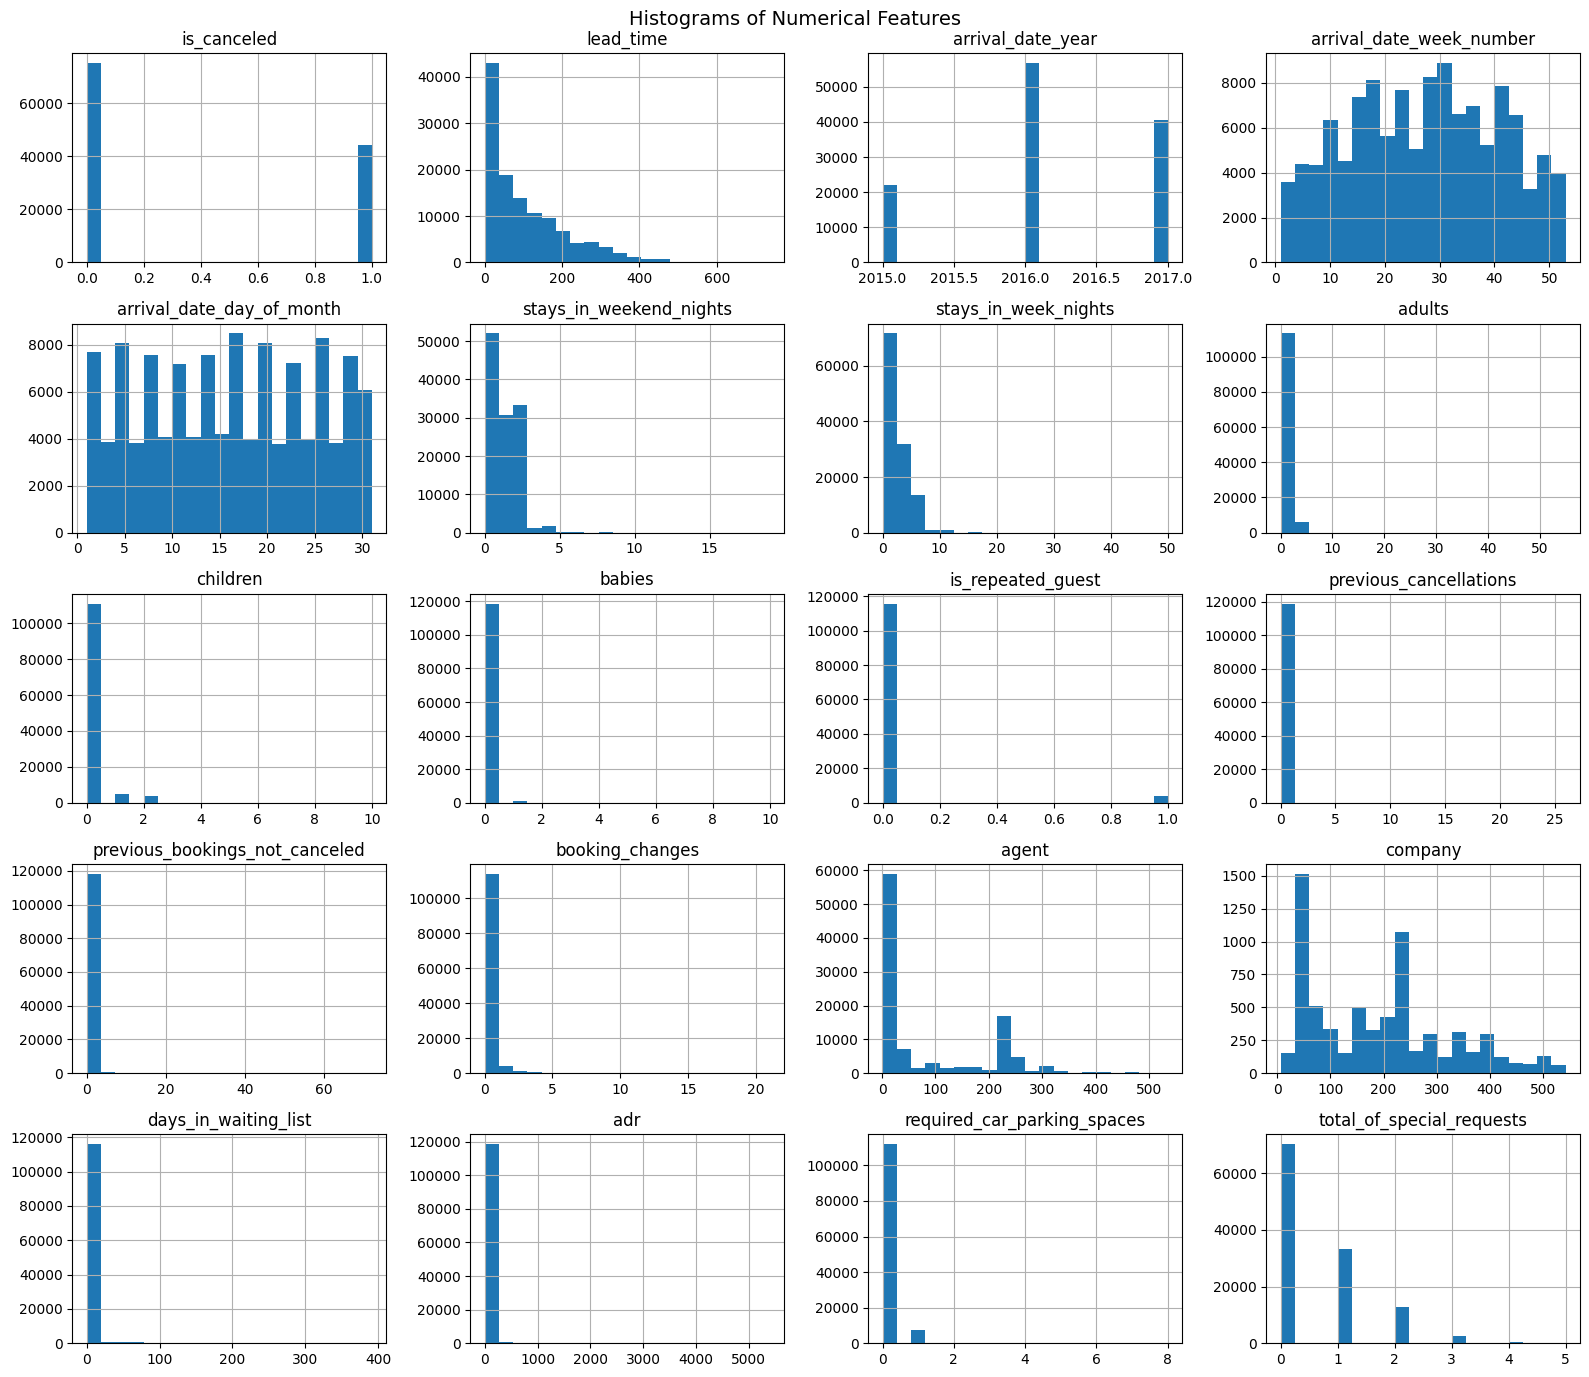

In [ ]:
numerical_data.hist(figsize=(16, 14), bins=20)
plt.suptitle("Histograms of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print("=== Unique values in Numerical Features ===")
print(numerical_data.nunique())

print("\n=== Unique values in Categorical Features ===")
print(categorical_data.nunique())

=== Unique values in Numerical Features ===
is_canceled                          2
lead_time                          479
arrival_date_year                    3
arrival_date_week_number            53
arrival_date_day_of_month           31
stays_in_weekend_nights             17
stays_in_week_nights                35
adults                              14
children                             5
babies                               5
is_repeated_guest                    2
previous_cancellations              15
previous_bookings_not_canceled      73
booking_changes                     21
agent                              333
company                            352
days_in_waiting_list               128
adr                               8879
required_car_parking_spaces          5
total_of_special_requests            6
dtype: int64

=== Unique values in Categorical Features ===
hotel                        2
arrival_date_month          12
meal                         5
country                

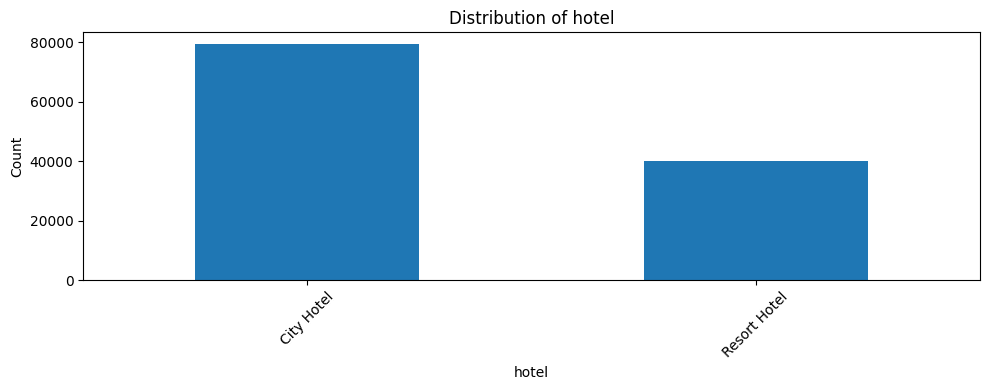

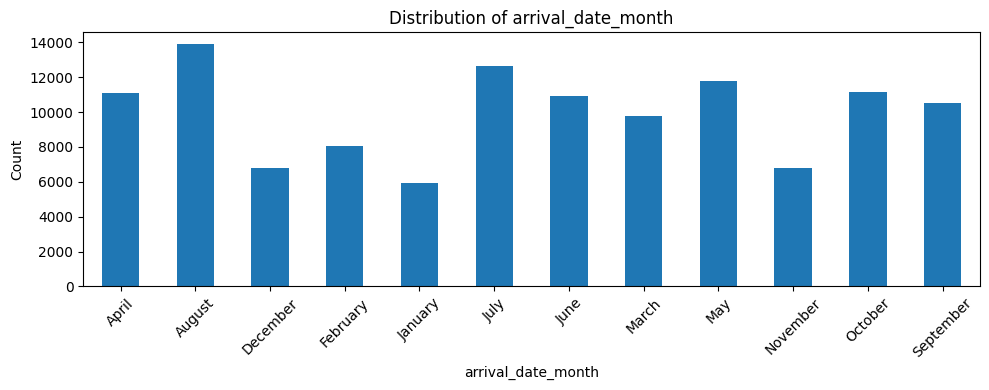

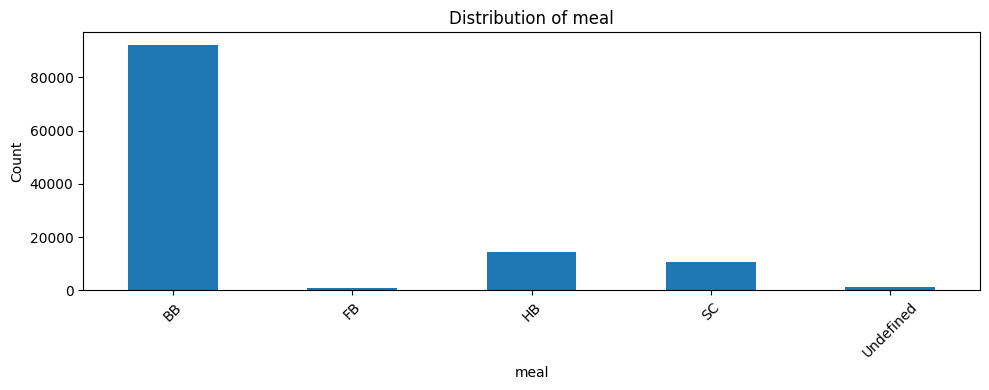

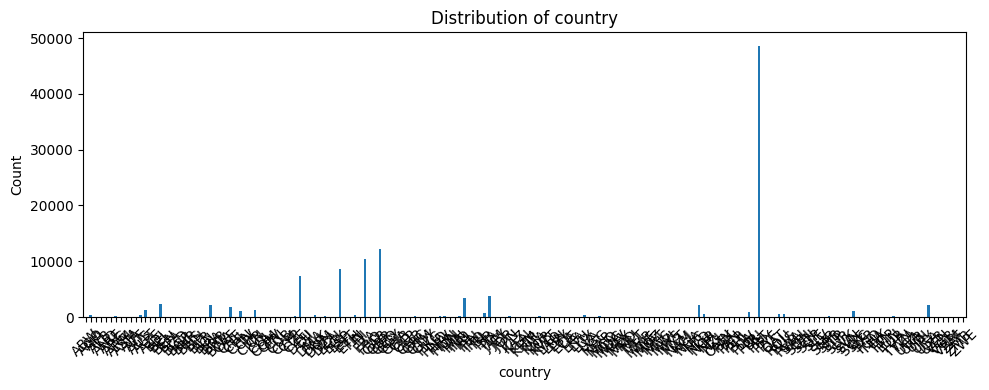

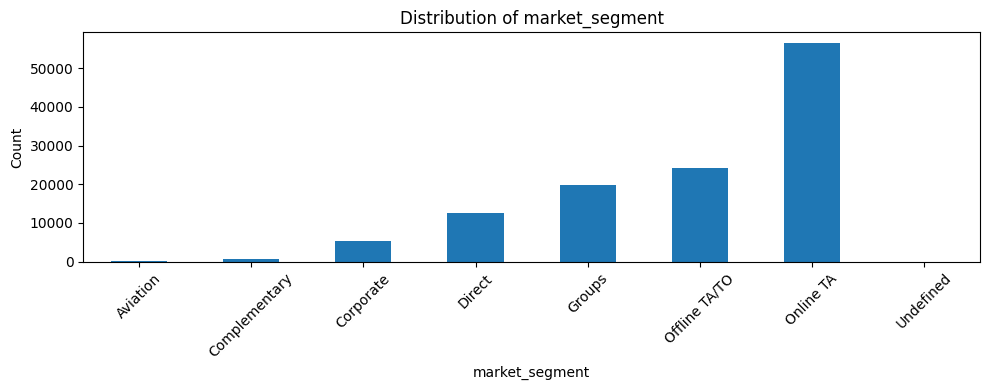

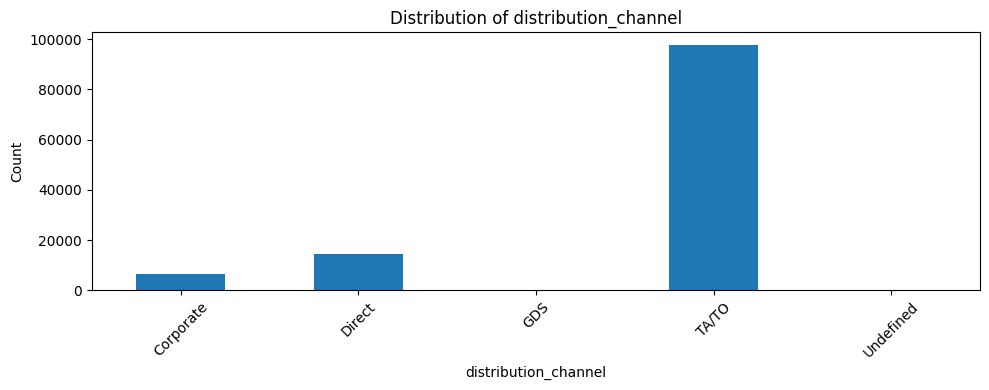

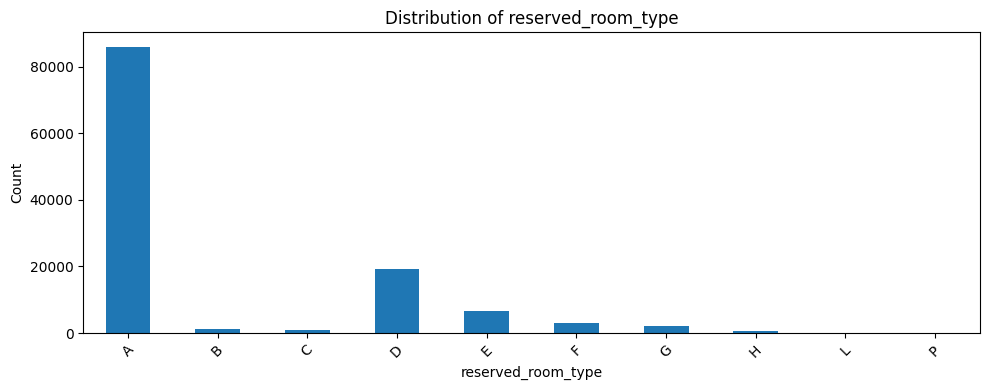

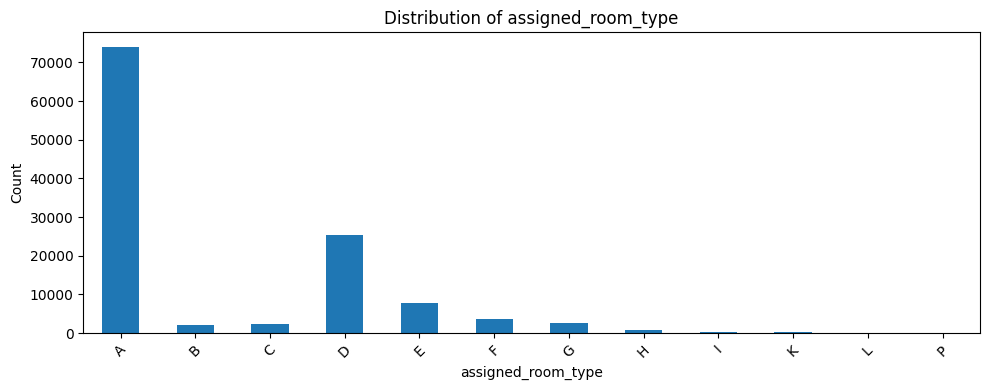

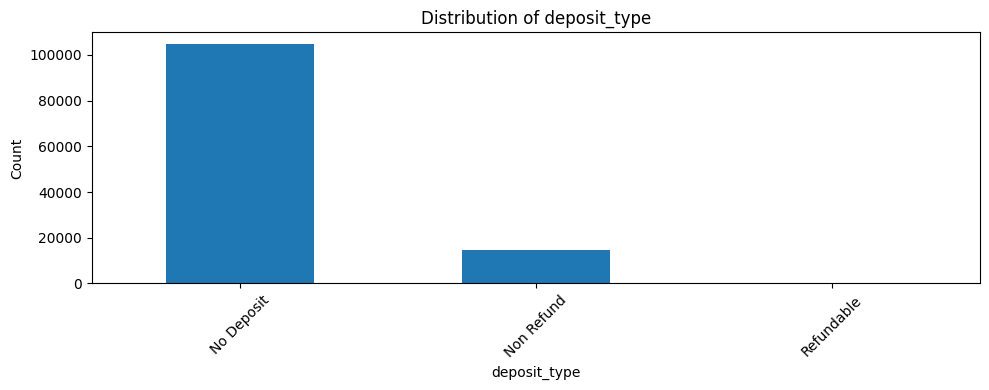

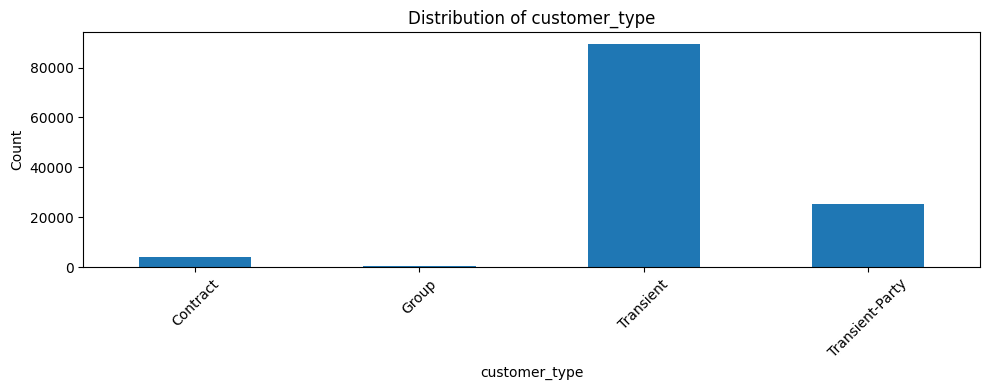

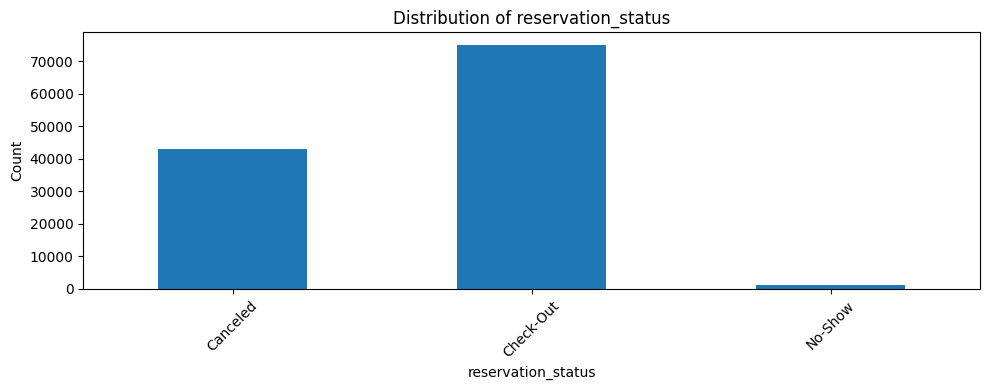

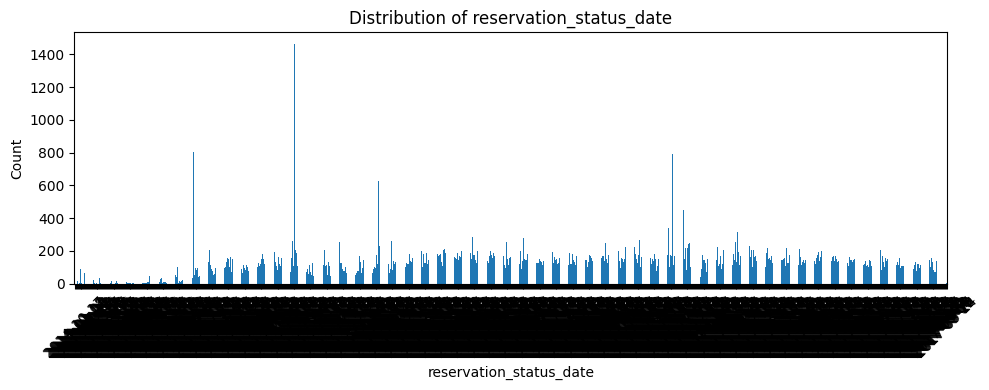

In [ ]:
for col in categorical_features:
    plt.figure(figsize=(10, 4))
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=45)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# **Heatmap**

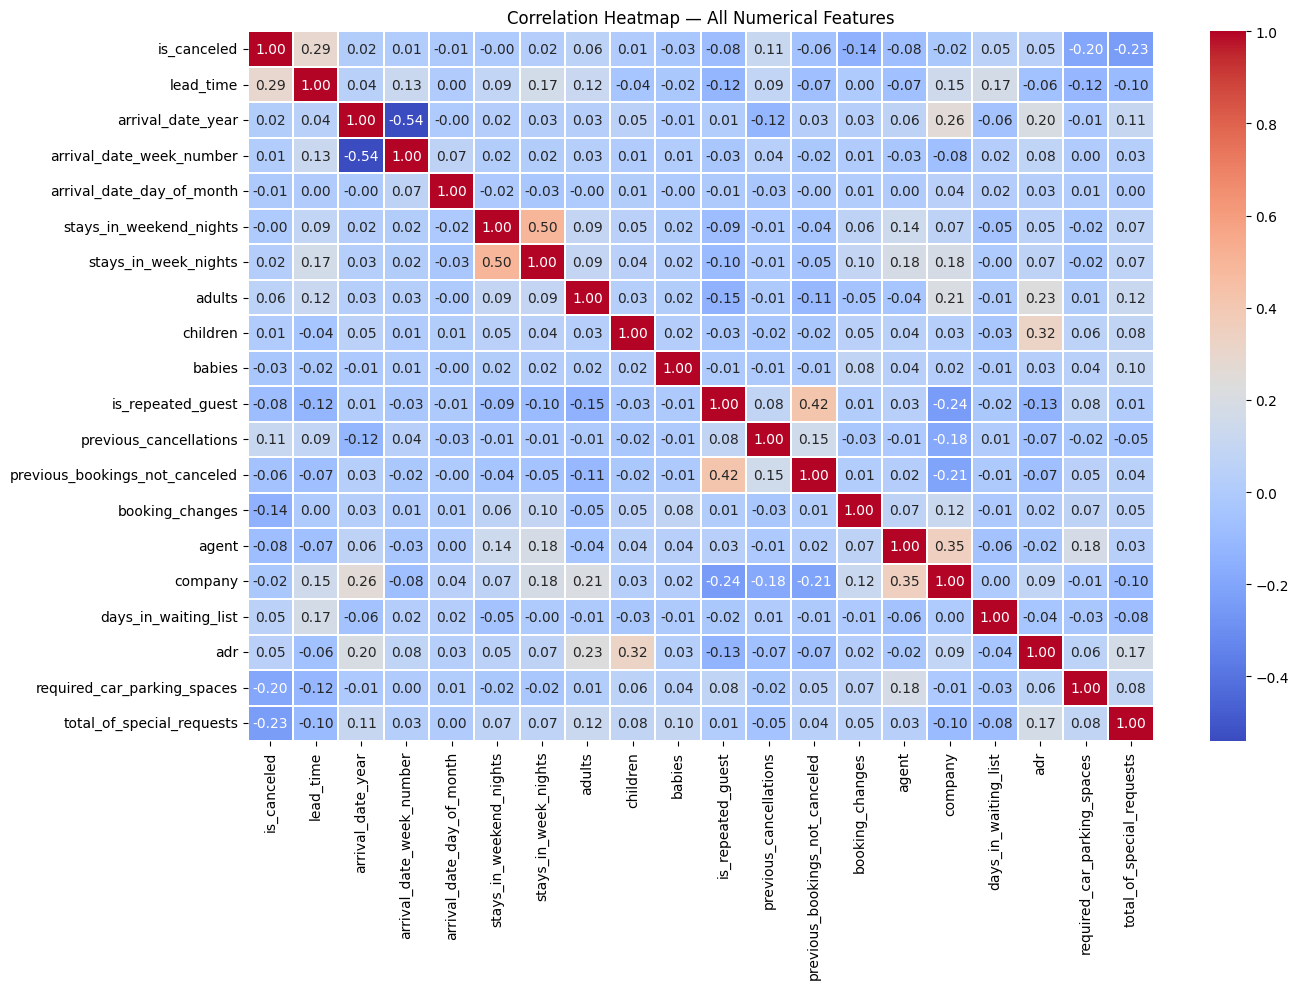

In [ ]:
correlation_matrix = numerical_data.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.3)
plt.title("Correlation Heatmap — All Numerical Features")
plt.tight_layout()
plt.show()

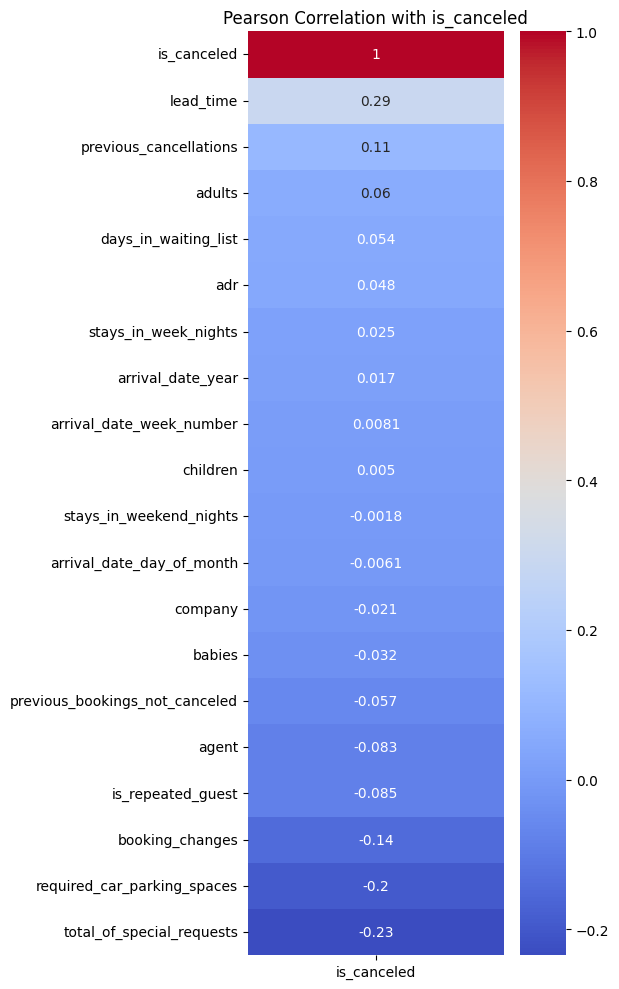

In [ ]:
corr = numerical_data.corr('pearson')[['is_canceled']].sort_values(by='is_canceled', ascending=False)

plt.figure(figsize=(6, 10))
plt.title('Pearson Correlation with is_canceled')

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.tight_layout()
plt.show()

   is_canceled  count  percentage
0            0  75166   62.958372
1            1  44224   37.041628


/tmp/ipykernel_6151/607967621.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imbalance_df, x='is_canceled', y='percentage', palette='Set2')


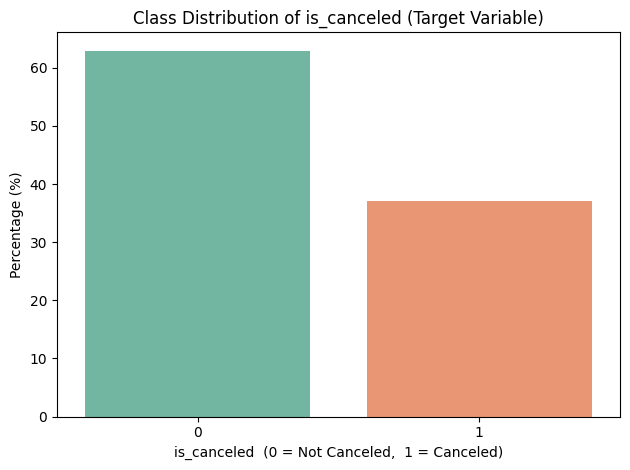

In [ ]:
class_counts = dataset.groupby("is_canceled").size()
total = dataset.shape[0]

outcome    = [0, 1]
count      = [class_counts[0], class_counts[1]]
percentage = [(class_counts[v] / total) * 100 for v in [0, 1]]

imbalance_df = pd.DataFrame({
    'is_canceled': outcome,
    'count': count,
    'percentage': percentage
})
print(imbalance_df)

sns.barplot(data=imbalance_df, x='is_canceled', y='percentage', palette='Set2')
plt.title("Class Distribution of is_canceled (Target Variable)")
plt.xlabel("is_canceled  (0 = Not Canceled,  1 = Canceled)")
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.show()

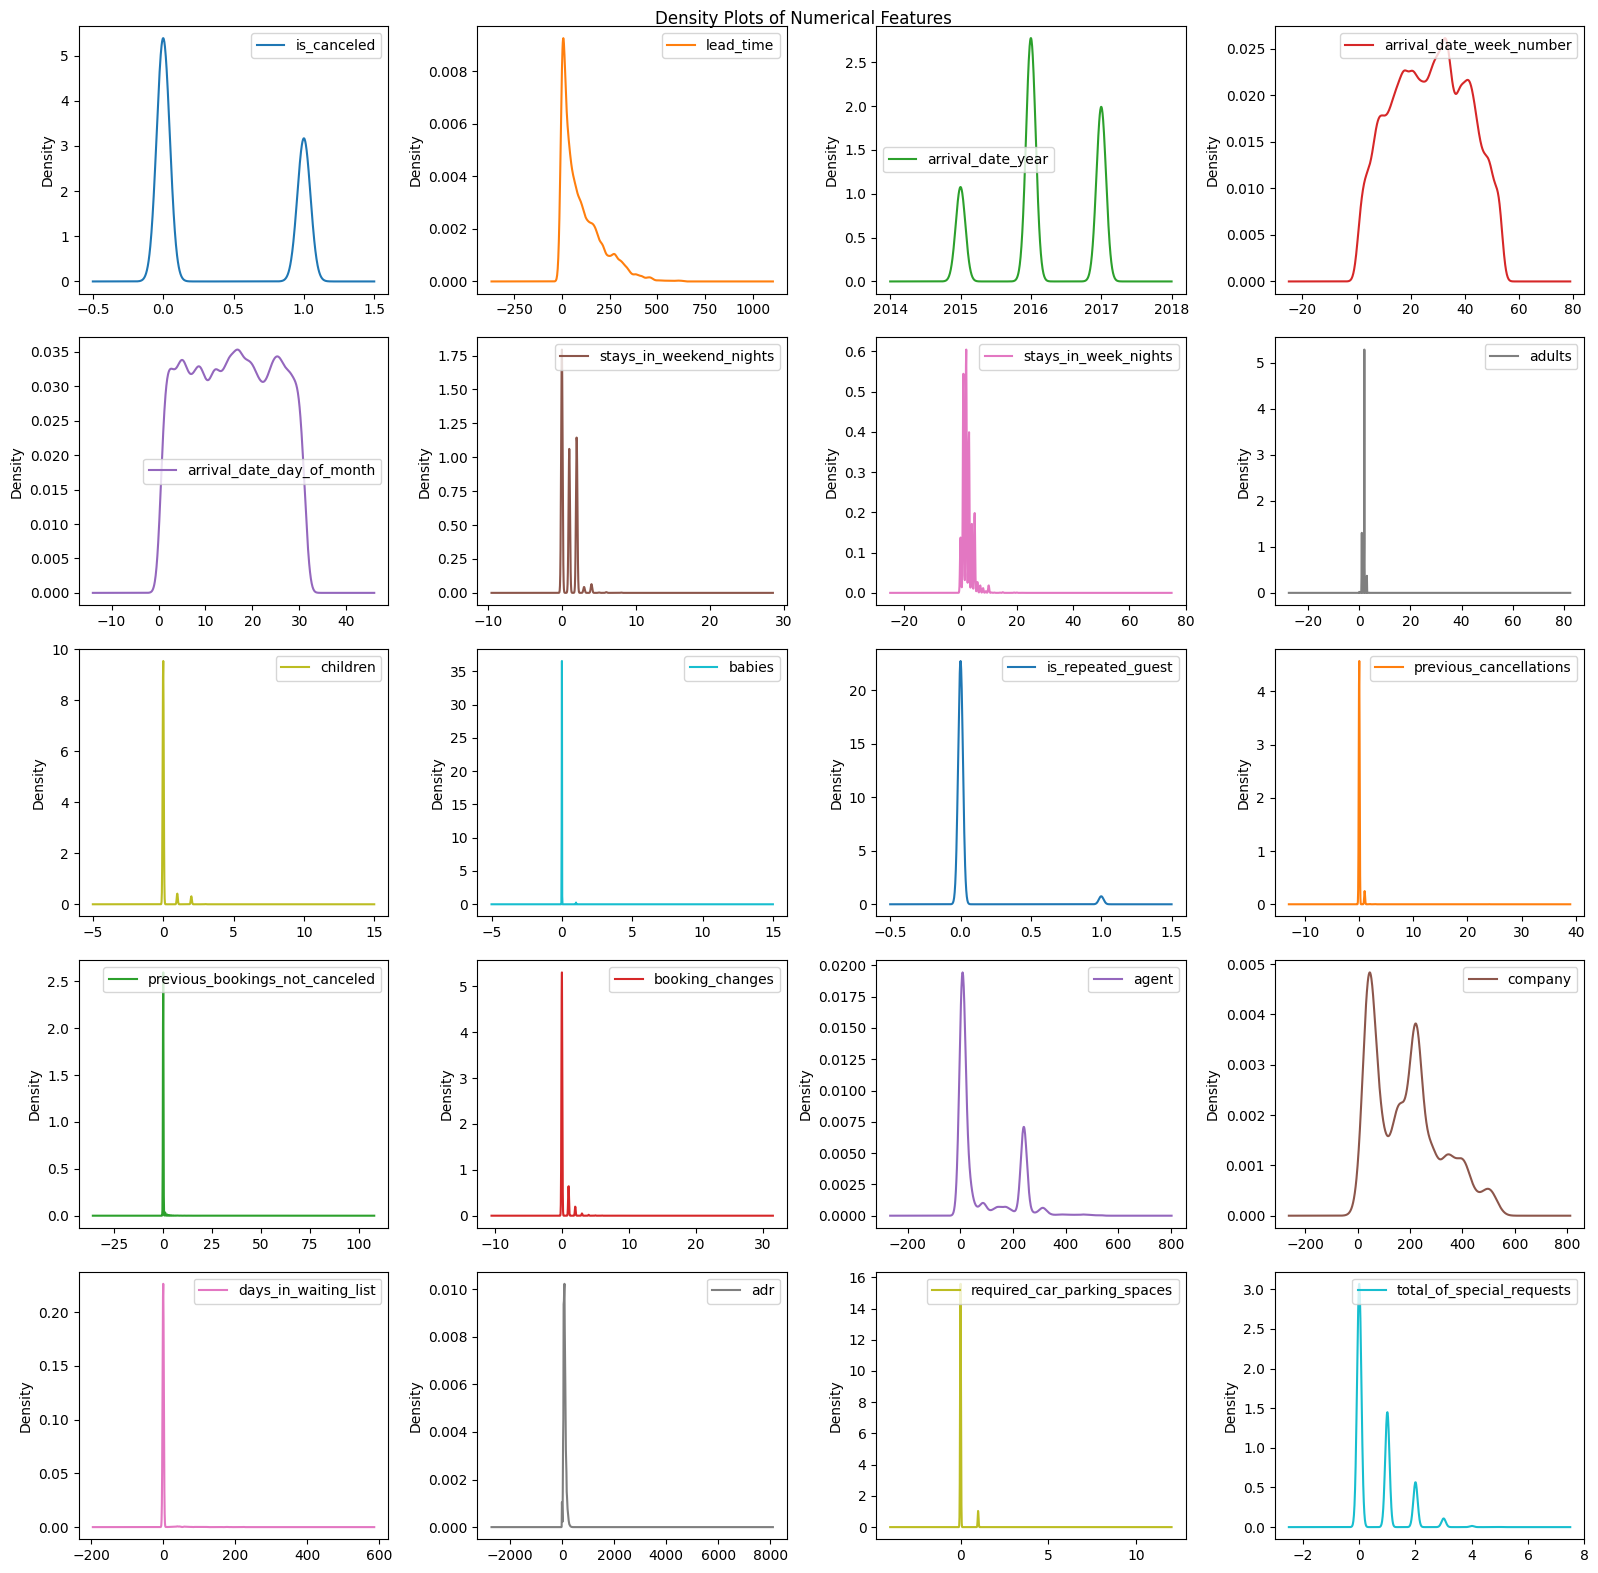

In [ ]:
numerical_data.plot(
    kind='density', figsize=(16, 16),
    subplots=True, layout=(5, 4),
    title="Density Plots of Numerical Features",
    sharex=False
)
plt.tight_layout()
plt.show()

In [ ]:
# Check missing values
print("=== Missing Values ===")
print(dataset.isnull().sum()[dataset.isnull().sum() > 0])

=== Missing Values ===
children         4
country        488
agent        16340
company     112593
dtype: int64


In [ ]:
# SOLUTION: Drop 'company' (too many nulls), impute others

# 'company' has mostly missing values — drop the column
dataset.drop(columns=['company'], inplace=True)

# 'agent' has missing values — fill with 0 (no agent)
dataset['agent'].fillna(0, inplace=True)

# 'children' has very few missing — fill with 0
dataset['children'].fillna(0, inplace=True)

# 'country' has very few missing — fill with mode
dataset['country'].fillna(dataset['country'].mode()[0], inplace=True)

# Verify
print("Missing values after fix:")
print(dataset.isnull().sum()[dataset.isnull().sum() > 0])
print("No remaining nulls!" if dataset.isnull().sum().sum() == 0 else "Still has nulls")

/tmp/ipykernel_6151/3709405678.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['agent'].fillna(0, inplace=True)
/tmp/ipykernel_6151/3709405678.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

Missing values after fix:
Series([], dtype: int64)
No remaining nulls!


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Check which columns need encoding
print("Categorical columns:", dataset.select_dtypes(include='object').columns.tolist())

Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


In [ ]:

# Drop 'reservation_status' — it directly leaks the target (data leakage!)
# Drop 'reservation_status_date' — date string, complex to use
dataset.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True)

# Label encode all remaining categorical columns
le = LabelEncoder()
categorical_cols = dataset.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    dataset[col] = le.fit_transform(dataset[col].astype(str))

print("Encoding done. Remaining object columns:", dataset.select_dtypes(include='object').columns.tolist())
dataset.head()

Encoding done. Remaining object columns: []


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,1,0,342,2015,5,27,1,0,0,2,...,2,2,3,0,0.0,0,2,0.0,0,0
1,1,0,737,2015,5,27,1,0,0,2,...,2,2,4,0,0.0,0,2,0.0,0,0
2,1,0,7,2015,5,27,1,0,1,1,...,0,2,0,0,0.0,0,2,75.0,0,0
3,1,0,13,2015,5,27,1,0,1,1,...,0,0,0,0,304.0,0,2,75.0,0,0
4,1,0,14,2015,5,27,1,0,2,2,...,0,0,0,0,240.0,0,2,98.0,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = dataset.drop(columns=['is_canceled'])
y = dataset['is_canceled']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaling done.")
X_scaled.describe().T

Scaling done.


,count,mean,std,min,25%,50%,75%,max
hotel,119390.0,-7.998739e-17,1.000004,-0.710619,-0.710619,-0.710619,1.407224,1.407224
lead_time,119390.0,6.094277e-17,1.000004,-0.973319,-0.804878,-0.327630,0.523930,5.923385
arrival_date_year,119390.0,-8.406294e-14,1.000004,-1.634768,-0.221286,-0.221286,1.192195,1.192195
arrival_date_month,119390.0,-6.856062e-17,1.000004,-1.553168,-0.987407,0.144115,0.709877,1.558519
arrival_date_week_number,119390.0,-1.295034e-16,1.000004,-1.923191,-0.820662,0.061361,0.796381,1.898910
arrival_date_day_of_month,119390.0,2.475800e-17,1.000004,-1.685297,-0.888102,0.022977,0.820172,1.731251
stays_in_weekend_nights,119390.0,1.197430e-16,1.000004,-0.928890,-0.928890,0.072502,1.073895,18.097569
stays_in_week_nights,119390.0,-2.761469e-17,1.000004,-1.310240,-0.786207,-0.262174,0.261858,24.891398
adults,119390.0,3.237585e-17,1.000004,-3.204792,0.247897,0.247897,0.247897,91.744169
children,119390.0,-3.999369e-17,1.000004,-0.260659,-0.260659,-0.260659,-0.260659,24.830072


In [ ]:
from sklearn.model_selection import train_test_split

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # stratified because dataset is imbalanced
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")
print(f"\nClass distribution in train:\n{y_train.value_counts(normalize=True)*100}")
print(f"\nClass distribution in test:\n{y_test.value_counts(normalize=True)*100}")

Train size: 95512 rows
Test size:  23878 rows

Class distribution in train:
is_canceled
0    62.958581
1    37.041419
Name: proportion, dtype: float64

Class distribution in test:
is_canceled
0    62.957534
1    37.042466
Name: proportion, dtype: float64


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.8345338805595108


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7932825194739928


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.47177318033336124


In [ ]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=42)
nn.fit(X_train, y_train)
nn_pred = nn.predict(X_test)
print("Neural Network Accuracy:", accuracy_score(y_test, nn_pred))

Neural Network Accuracy: 0.8602898065164587


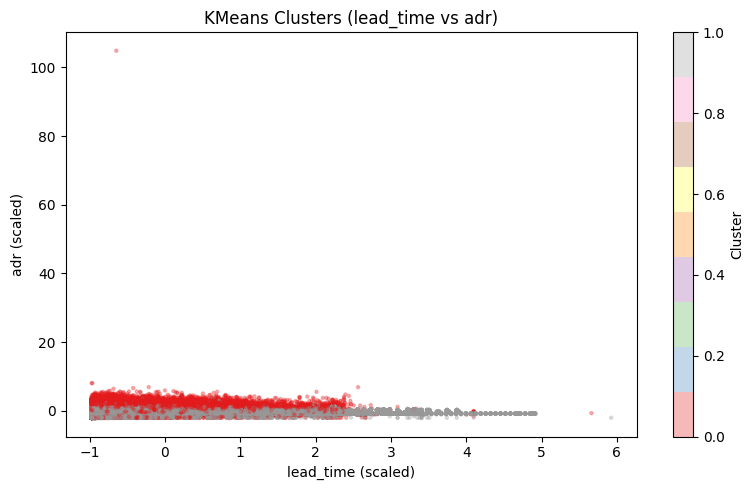

In [ ]:
#unsupervised kmeans

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_

# Visualize
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled['lead_time'], X_scaled['adr'],
            c=cluster_labels, cmap='Set1', alpha=0.3, s=5)
plt.title("KMeans Clusters (lead_time vs adr)")
plt.xlabel("lead_time (scaled)")
plt.ylabel("adr (scaled)")
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

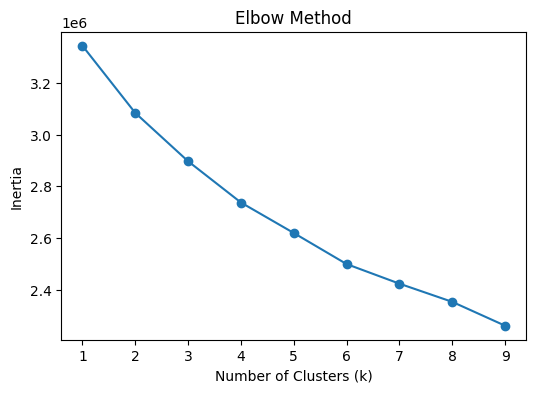

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, roc_curve)

models_pred = {
    'KNN': knn_pred,
    'Logistic Regression': lr_pred,
    'Naive Bayes': nb_pred,
    'Neural Network': nn_pred
}

models_obj = {
    'KNN': knn,
    'Logistic Regression': lr,
    'Naive Bayes': nb,
    'Neural Network': nn
}

results = []
for name, pred in models_pred.items():
    proba = models_obj[name].predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

                     Accuracy  Precision  Recall     AUC
Model                                                   
KNN                    0.8345     0.7892  0.7549  0.9001
Logistic Regression    0.7933     0.8044  0.5839  0.8637
Naive Bayes            0.4718     0.4105  0.9766  0.8013
Neural Network         0.8603     0.8334  0.7785  0.9360


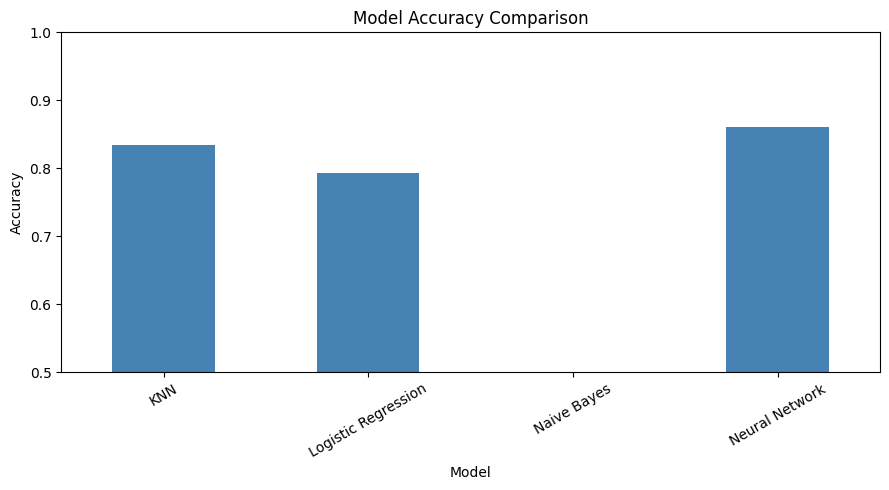

In [ ]:
#bar chart accuracy
results_df['Accuracy'].plot(kind='bar', figsize=(9, 5), color='steelblue', rot=30)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

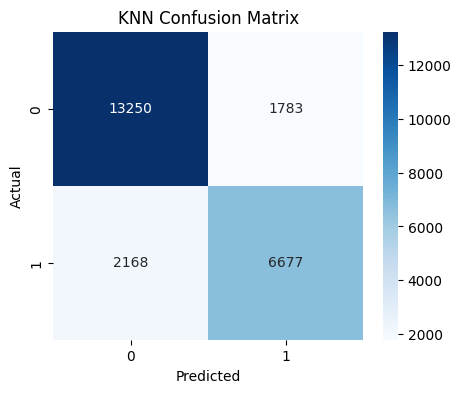

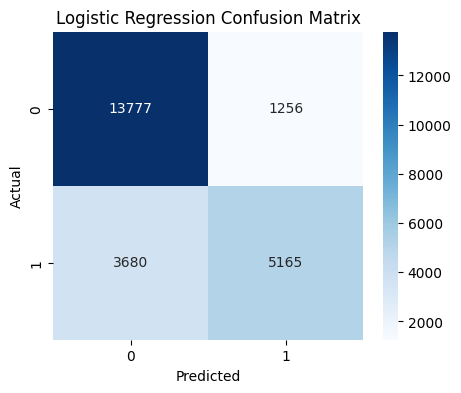

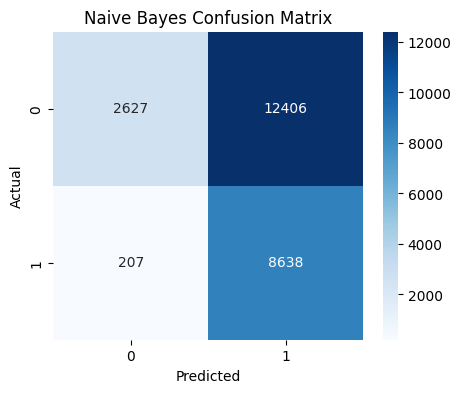

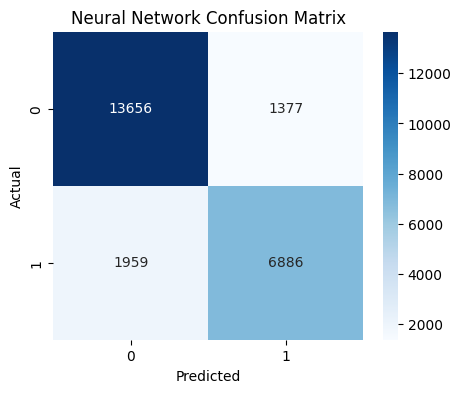

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, pred in models_pred.items():
    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

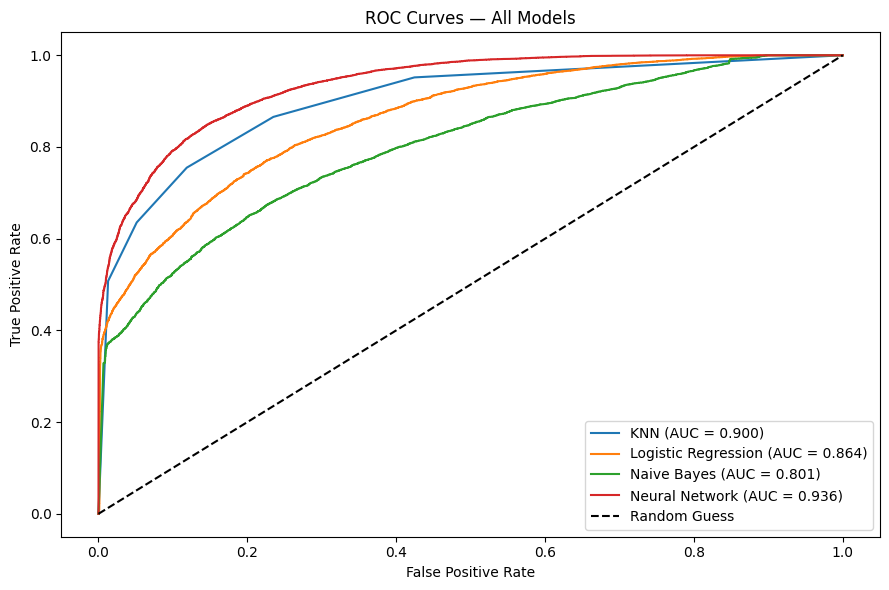

In [ ]:
#roc auc
plt.figure(figsize=(9, 6))
for name, obj in models_obj.items():
    proba = obj.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title("ROC Curves — All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()